# Features Generation Validation Analysis: Variability and Accuracy of the Predictions

In [8]:
import os
import json
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import seaborn as sns
import sys 
import numpy as np
from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix

In [9]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')
sys.path.append(project_path)
validation_results_dir = os.path.join(project_path, 'data', 'validation_results')

from config.config_03bcd_04bc import (
    FEATURE_CONFIG
)

feature_names = FEATURE_CONFIG.keys()

In [10]:
validation_results, true_predicted_values_df, df_plot = {}, {}, {}

for feature_name in feature_names:

    try:
        validation_results_path = os.path.join(validation_results_dir, f'validation_results_{feature_name}.json')
        true_predicted_values_df_path = os.path.join(validation_results_dir, f'true_predicted_values_{feature_name}.parquet')
        df_plot_path = os.path.join(validation_results_dir, f'plot_true_predicted_values_{feature_name}.csv')
        
        with open(validation_results_path, 'r', encoding='utf-8') as f:
            validation_results[feature_name] = json.load(f)
        true_predicted_values_df[feature_name] = pl.read_parquet(true_predicted_values_df_path)
        df_plot[feature_name] = pl.read_csv(df_plot_path)
        print(f'✅ {feature_name} read correctly\n')
    except Exception as e: 
        print(f'❌ Error for {feature_name}: {e}')

✅ content_relevance_score read correctly

❌ Error for political_stance_score: [Errno 2] No such file or directory: 'c:\\Users\\fscielzo\\Documents\\PhD\\paper-4\\src\\notebooks\\..\\..\\data\\validation_results\\validation_results_political_stance_score.json'
❌ Error for argument_quality_score: [Errno 2] No such file or directory: 'c:\\Users\\fscielzo\\Documents\\PhD\\paper-4\\src\\notebooks\\..\\..\\data\\validation_results\\validation_results_argument_quality_score.json'
❌ Error for sentiment_score: [Errno 2] No such file or directory: 'c:\\Users\\fscielzo\\Documents\\PhD\\paper-4\\src\\notebooks\\..\\..\\data\\validation_results\\validation_results_sentiment_score.json'
❌ Error for discourse_tone_score: [Errno 2] No such file or directory: 'c:\\Users\\fscielzo\\Documents\\PhD\\paper-4\\src\\notebooks\\..\\..\\data\\validation_results\\validation_results_discourse_tone_score.json'
❌ Error for dominant_frame_score: [Errno 2] No such file or directory: 'c:\\Users\\fscielzo\\Documents\\

In [11]:
for feature_name in feature_names:

    try:
        display(true_predicted_values_df[feature_name])
    except Exception as e: 
        print(e)

comment_id,content_relevance_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,i64,list[i64],f64,f64,i64,f64,f64
"""njv8x1o""",4,"[4, 4, 4]",4.0,0.0,4,1.0,0.0
"""mv880d6""",5,"[4, 4, 4]",4.0,0.0,4,1.0,0.0
"""ncmr4po""",0,"[0, 0, 0]",0.0,0.0,0,1.0,0.0
"""mc1mog9""",0,"[0, 0, 0]",0.0,0.0,0,1.0,0.0
"""npna0go""",1,"[5, 5, 5]",5.0,0.0,5,1.0,0.0
…,…,…,…,…,…,…,…
"""m937cx3""",0,"[0, 1, 1]",0.67,0.58,1,0.666667,0.333333
"""mkdp0lv""",0,"[3, 2, 2]",2.33,0.58,2,0.666667,0.333333
"""njn6kli""",5,"[4, 4, 3]",3.67,0.58,4,0.666667,0.333333


'political_stance_score'
'argument_quality_score'
'sentiment_score'
'discourse_tone_score'
'dominant_frame_score'


In [12]:
for feature_name in feature_names:

    try:
        feature_type = FEATURE_CONFIG[feature_name]['type']
        
        print(f'📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: {feature_name.upper()} ({feature_type})')
        print('-' * 75)
        
        score_values = validation_results[feature_name]['individual_validation']['score_value']
        avg_score = np.mean(score_values)
        cv_score_values_std = np.abs(np.std(score_values) / np.mean(score_values))
        prob_validation_passed = validation_results['content_relevance_score']['global_validation']['prob_validation_passed']
        validation_threshold = validation_results['content_relevance_score']['individual_validation']['validation_threshold']

        # --- A. MÉTRICAS DE EXACTITUD ALINEADAS CON VALIDACIÓN OFICIAL ---

        if feature_name == 'content_relevance_score':
            cutoff = FEATURE_CONFIG[feature_name].get('cutoff', 3) # Asegúrate de que existe
            print(f"  🎯 Exactitud Binaria (Umbral >={cutoff}): {avg_score:.2%} (Avg Score de las Validaciones Individuales)")
            
        elif feature_type == 'ordinal':
            print(f"  🎯 Exactitud Media Adyacente (+/- 1 tolerancia): {avg_score:.2%} (Avg Score de las Validaciones Individuales)")

        elif feature_type == 'continuous':
            print(f"  📉 Error Absoluto Medio (MAE): {avg_score:.4f} (Avg Score de las Validaciones Individuales)")

        elif feature_type == 'categorical':
            print(f"  🎯 Exactitud Categórica: {avg_score:.2%} (Avg Score de las Validaciones Individuales)")

        print(f"  🎯 Probabilidad de superar la validación: {prob_validation_passed:.2%} (% de iteraciones con validación superada) (validation score threshold >={validation_threshold:.2%}): ")

        if feature_type in ['continuous']:

            # --- B. MÉTRICAS DE VARIABILIDAD (Consistencia Intra-LLM) ---
            # Usamos el .mean() nativo del DataFrame que ignora los nulos automáticamente
            cv_std = true_predicted_values_df[feature_name]['predicted_values_cv_std'].mean()
            cv_qnt = true_predicted_values_df[feature_name]['predicted_values_cv_quantiles'].mean()
            cv_rng = true_predicted_values_df[feature_name]['predicted_values_cv_range'].mean()
            
            
            # Salvaguarda: si toda la columna era nula, mean() devuelve None o NaN. 
            # Lo pasamos a 0.0 para que no falle el formateo del print (.2%)
            cv_std = cv_std if cv_std is not None and not np.isnan(cv_std) else 0.0
            cv_qnt = cv_qnt if cv_qnt is not None and not np.isnan(cv_qnt) else 0.0
            cv_rng = cv_rng if cv_rng is not None and not np.isnan(cv_rng) else 0.0
            
            print(f"\n  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):")
            print(f"     - coefficient of variation Predictions (Std Dev): {cv_std:.2%}")
            print(f"     - coefficient of variation Predictions(Cuartiles): {cv_qnt:.2%}")
            print(f"     - coefficient of variation Predictions(Rango): {cv_rng:.2%}")
            print(f"     - coefficient of variation Score Metric (Std Dev): {cv_score_values_std:.2%}\n")


        elif feature_type in ['ordinal', 'categorical']:
            
            var_nomoda = true_predicted_values_df[feature_name]['predicted_values_variability'].mean()
            print(f"\n  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):")
            print(f"     - Frecuencia de la No-Moda: {var_nomoda:.2%} (% medio de predicciones que difieren de la predicción moda)")
            print(f"     - coefficient of variation Score Metric (Std Dev): {cv_score_values_std:.2%}\n")
            
    except Exception as e: 
        print(f'{feature_name}: {e}')

📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: CONTENT_RELEVANCE_SCORE (ordinal)
---------------------------------------------------------------------------
  🎯 Exactitud Binaria (Umbral >=3): 72.00% (Avg Score de las Validaciones Individuales)
  🎯 Probabilidad de superar la validación: 0.00% (% de iteraciones con validación superada) (validation score threshold >=75.00%): 

  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):
     - Frecuencia de la No-Moda: 10.00% (% medio de predicciones que difieren de la predicción moda)
     - coefficient of variation Score Metric (Std Dev): 0.00%

📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: POLITICAL_STANCE_SCORE (ordinal)
---------------------------------------------------------------------------
political_stance_score: 'political_stance_score'
📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: ARGUMENT_QUALITY_SCORE (ordinal)
---------------------------------------------------------------------------
argument_quality_score: 'argument_quality_sco

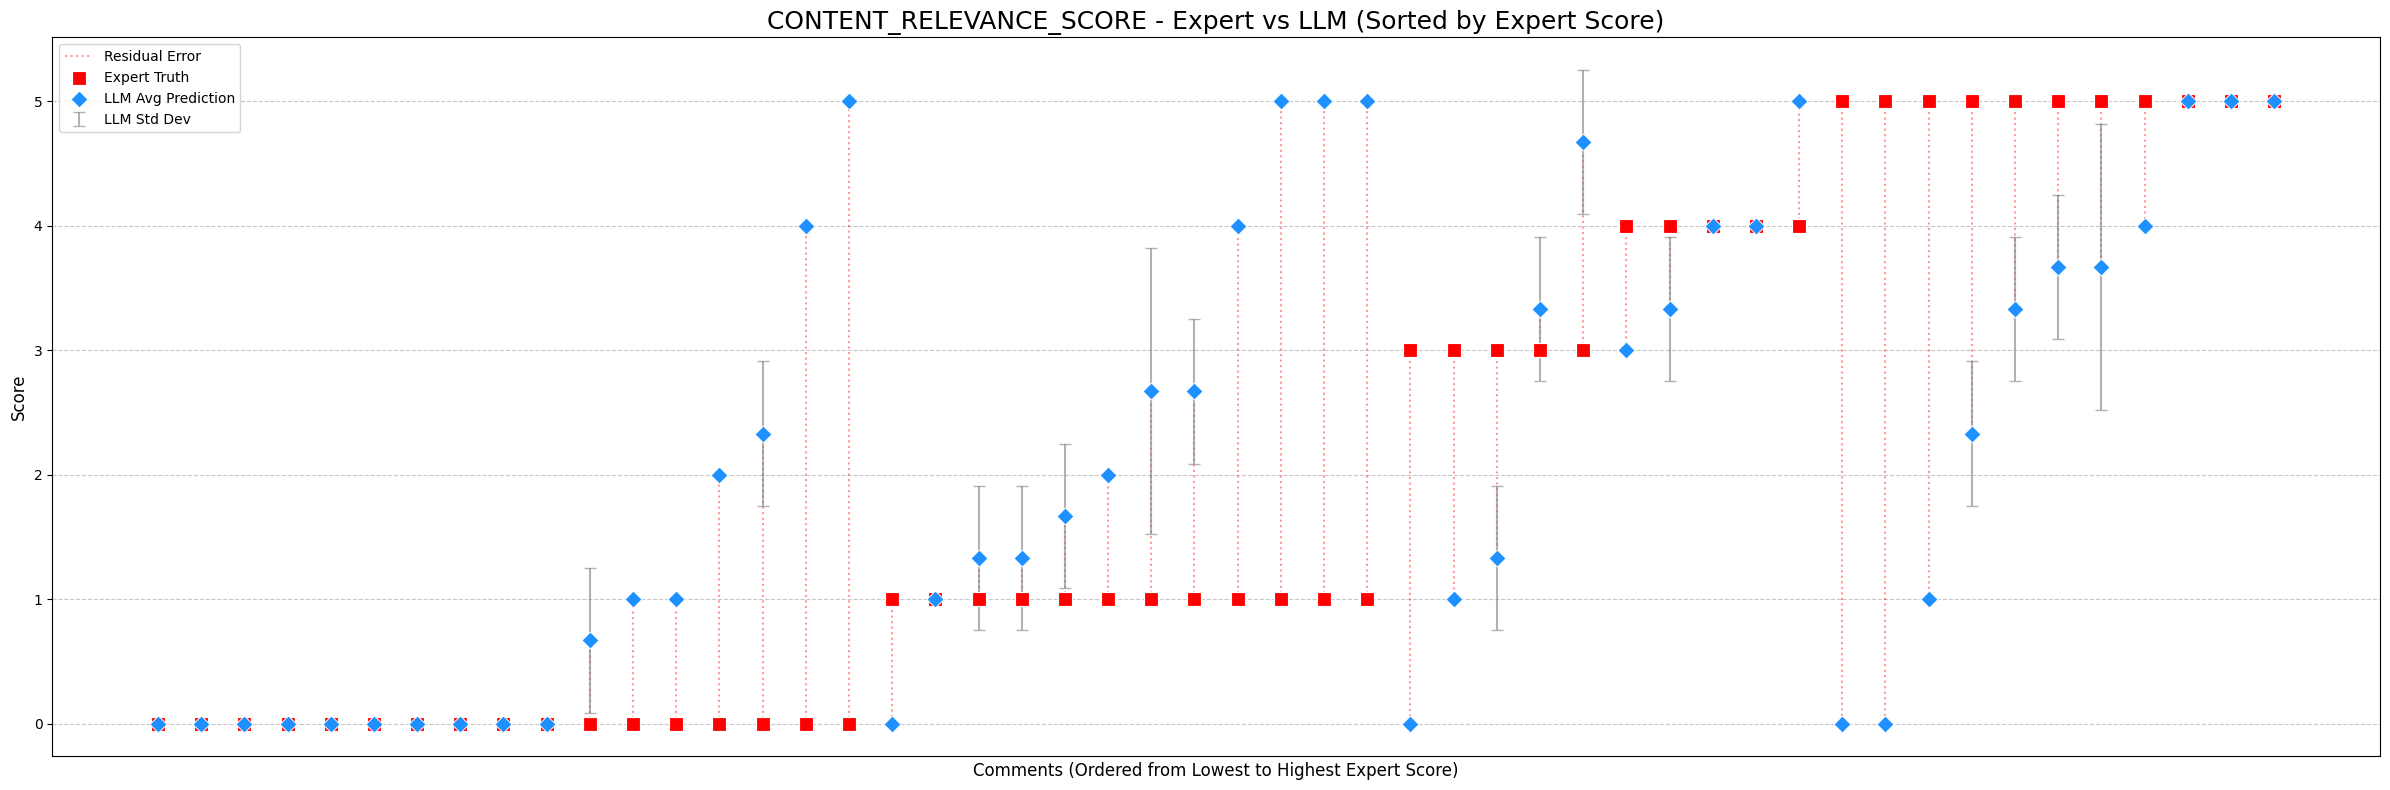

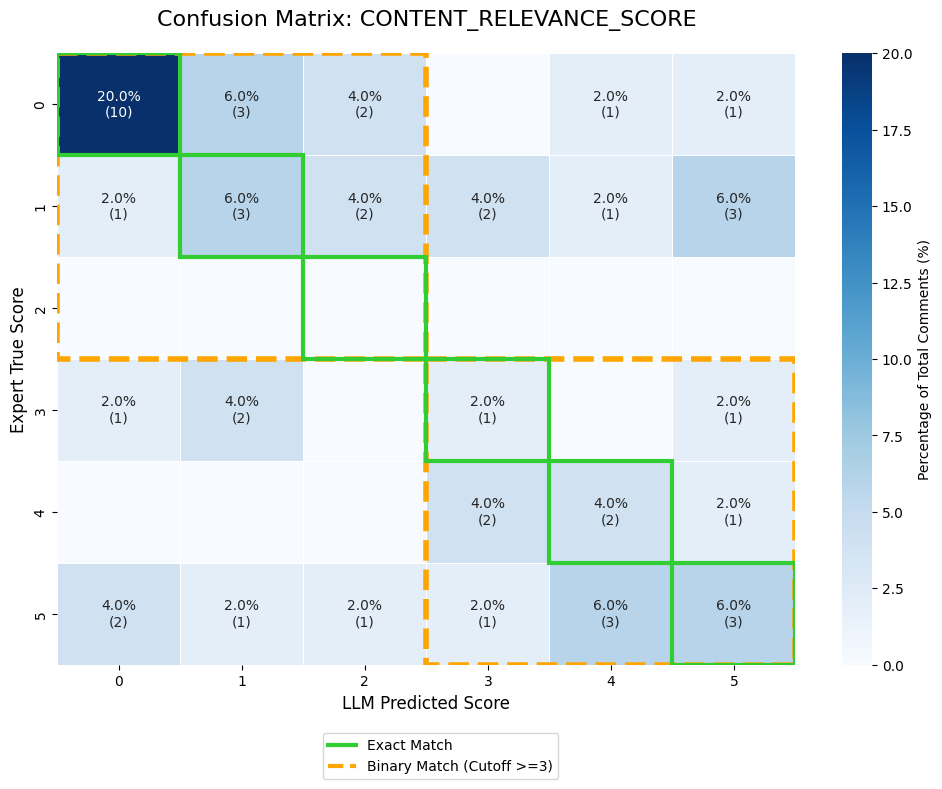

Exception: 'political_stance_score'
Exception: 'argument_quality_score'
Exception: 'sentiment_score'
Exception: 'discourse_tone_score'
Exception: 'dominant_frame_score'


In [13]:
for feature_name in feature_names:

    try: 
        feature_type = FEATURE_CONFIG[feature_name]['type']
        
        # Deduplicamos para tener 1 fila por comment_id
        df_feat_unique = df_plot[feature_name].unique(subset=["comment_id"], keep="first", maintain_order=True)

        # =====================================================================
        # 1. VISUALIZACIONES PARA VARIABLES ORDINALES Y CONTINUAS
        # =====================================================================
        if feature_type in ['ordinal', 'continuous']:
            
            # --- A. SCATTER PLOT ORDENADO (Staircase Plot) ---
            df_sorted = df_feat_unique.sort([feature_name, "predicted_values_mean"]).with_row_index(name="plot_index")
            plt.figure(figsize=(24, 8))

            plot_idx = df_sorted["plot_index"].to_numpy()
            y_mean = df_sorted["predicted_values_mean"].to_numpy()
            y_std = df_sorted["predicted_values_std"].to_numpy()
            y_true = df_sorted[feature_name].to_numpy()

            # Variabilidad y Error
            plt.errorbar(x=plot_idx, y=y_mean, yerr=y_std, fmt='none', ecolor='gray', elinewidth=1.5, capsize=4, alpha=0.6, zorder=5, label='LLM Std Dev')
            plt.vlines(x=plot_idx, ymin=y_true, ymax=y_mean, colors='red', linestyles='dotted', alpha=0.4, linewidth=1.5, label='Residual Error')

            df_sns = df_sorted.to_pandas()
            sns.scatterplot(data=df_sns, x="plot_index", y=feature_name, color="red", s=110, marker="s", label="Expert Truth", zorder=10)
            sns.scatterplot(data=df_sns, x="plot_index", y="predicted_values_mean", color="dodgerblue", s=75, marker="D", label="LLM Avg Prediction", zorder=11)

            plt.title(f"{feature_name.upper()} - Expert vs LLM (Sorted by Expert Score)", fontsize=18)
            plt.xlabel("Comments (Ordered from Lowest to Highest Expert Score)", fontsize=12)
            plt.ylabel("Score", fontsize=12)
            plt.xticks([]) 
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.legend(loc='upper left')
            plt.tight_layout()
            plt.show()

            # --- B. MATRIZ DE CONFUSIÓN CON % Y CUADRANTES BINARIOS ---
            if feature_type == 'ordinal':
                y_true_cm = df_feat_unique[feature_name].cast(pl.Int32).to_list()
                y_pred_cm = df_feat_unique["predicted_values_mean"].round(0).cast(pl.Int32).to_list()
                
                classes = sorted(list(set(y_true_cm) | set(y_pred_cm)))
                cm = confusion_matrix(y_true_cm, y_pred_cm, labels=classes)
                cm_perc = (cm / np.sum(cm)) * 100
                
                # Anotaciones limpias (solo si > 0)
                annot_data = np.empty_like(cm, dtype=object)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        annot_data[i, j] = f"{cm_perc[i, j]:.1f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

                fig, ax = plt.subplots(figsize=(10, 8))
                sns.heatmap(cm_perc, annot=annot_data, fmt='', cmap='Blues', xticklabels=classes, yticklabels=classes,
                            linewidths=.5, cbar_kws={'label': 'Percentage of Total Comments (%)'}, ax=ax)
                
                # 1. Diagonal: Aciertos Puros
                for i in range(len(classes)):
                    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='limegreen', lw=3, zorder=10))

                # 2. Cuadrantes: Aciertos Binarios (Basados en el cutoff)
                cutoff = FEATURE_CONFIG[feature_name].get('cutoff', 3) # Extraemos el cutoff, por defecto 3
                
                # Buscamos en qué índice de la matriz cae el cutoff
                split_idx = next((i for i, c in enumerate(classes) if c >= cutoff), None)
                
                if split_idx is not None and split_idx > 0:
                    # Caja de Verdaderos Negativos (< cutoff)
                    ax.add_patch(patches.Rectangle(
                        (0, 0), split_idx, split_idx, 
                        fill=False, edgecolor='orange', lw=4, ls='--', zorder=9
                    ))
                    # Caja de Verdaderos Positivos (>= cutoff)
                    ax.add_patch(patches.Rectangle(
                        (split_idx, split_idx), len(classes) - split_idx, len(classes) - split_idx, 
                        fill=False, edgecolor='orange', lw=4, ls='--', zorder=9
                    ))

                plt.title(f"Confusion Matrix: {feature_name.upper()}", fontsize=16, pad=20)
                plt.xlabel("LLM Predicted Score", fontsize=12)
                plt.ylabel("Expert True Score", fontsize=12)
                
                # Leyendas manuales
                pure_hit_line = mlines.Line2D([], [], color='limegreen', lw=3, label='Exact Match')
                binary_hit_line = mlines.Line2D([], [], color='orange', lw=3, linestyle='--', label=f'Binary Match (Cutoff >={cutoff})')
                ax.legend(handles=[pure_hit_line, binary_hit_line], loc='upper left', bbox_to_anchor=(0.35, -0.1))
                
                plt.tight_layout()
                plt.show()

        # =====================================================================
        # 2. VISUALIZACIONES PARA VARIABLES CATEGÓRICAS
        # =====================================================================
        elif feature_type == 'categorical':
            
            pred_col = "predicted_category_mode" 
            if pred_col in df_feat_unique.columns:
                try:
                    y_true_cat = df_feat_unique[feature_name].cast(pl.String).to_list()
                    y_pred_cat = df_feat_unique[pred_col].cast(pl.String).to_list()
                except AttributeError:
                    y_true_cat = df_feat_unique[feature_name].cast(pl.Utf8).to_list()
                    y_pred_cat = df_feat_unique[pred_col].cast(pl.Utf8).to_list()
                
                classes = sorted(list(set(y_true_cat) | set(y_pred_cat)))
                cm = confusion_matrix(y_true_cat, y_pred_cat, labels=classes)
                cm_perc = (cm / np.sum(cm)) * 100
                
                # Anotaciones limpias (solo si > 0)
                annot_data = np.empty_like(cm, dtype=object)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        annot_data[i, j] = f"{cm_perc[i, j]:.1f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

                fig, ax = plt.subplots(figsize=(12, 10))
                sns.heatmap(cm_perc, annot=annot_data, fmt='', cmap='Purples', xticklabels=classes, yticklabels=classes,
                            linewidths=.5, cbar_kws={'label': 'Percentage of Total Comments (%)'}, ax=ax)
                
                # Resaltar la diagonal principal (Aciertos en clases categóricas)
                for i in range(len(classes)):
                    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='limegreen', lw=3, zorder=10))

                plt.title(f"Categorical Confusion Matrix: {feature_name.upper()}", fontsize=16, pad=20)
                plt.xlabel("LLM Predicted Category", fontsize=12)
                plt.ylabel("Expert True Category", fontsize=12)
                plt.xticks(rotation=45, ha='right')
                
                pure_hit_line = mlines.Line2D([], [], color='limegreen', lw=3, label='Exact Match')
                ax.legend(handles=[pure_hit_line], loc='upper left', bbox_to_anchor=(0.35, -0.1))
                
                plt.tight_layout()
                plt.show()
    except Exception as e:
        print(f"Exception: {e}")        